In [1]:
from main.scheduler import EDMScheduler
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
import torch

In [2]:
#Load a scheduler using a config file
daps_config_yaml = 'configs/daps_config/edm_daps.yaml'
daps_config = OmegaConf.load(daps_config_yaml)

In [26]:
import torch
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler, VQModel
from model import DiffusionModel, register_model

@register_model(name='ldm-celebahq-256')
class MyLDMModel(DiffusionModel):
    def __init__(self, num_steps=20):
        super().__init__()
        model_id = "CompVis/ldm-celebahq-256"
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.unet = UNet2DModel.from_pretrained(model_id, subfolder="unet")
        self.unet.to(self.device)
        self.unet.eval()

        self.vqvae = VQModel.from_pretrained(model_id, subfolder="vqvae")
        self.vqvae.to(self.device)
        self.vqvae.eval()

        self.ddim_scheduler = DDIMScheduler.from_config(model_id, subfolder="scheduler")
        self.alphas_cumprod = self.ddim_scheduler.alphas_cumprod.to(self.device)

        self.edm_scheduler = EDMScheduler(num_steps=num_steps)

    def _get_timestep_from_sigma(self, sigma):
        """Maps continuous EDM noise level (sigma) to discrete LDM timestep (t)."""
        if not torch.is_tensor(sigma):
            sigma = torch.tensor(sigma, device=self.device)
        
        target_alpha = 1 / (sigma ** 2 + 1)
        
        diff = torch.abs(self.alphas_cumprod - target_alpha)
        t = torch.argmin(diff)
        return t

    def _scale_input(self, x, sigma):
        """Preconditions input from EDM high-variance to LDM unit-variance."""
        scale = torch.sqrt(sigma ** 2 + 1)
        return x / scale

    def get_in_shape(self):
        """
        Returns the LATENT shape, not the image shape.
        For CompVis/ldm-celebahq-256, latents are 3 channels, 64x64.
        """
        return (self.unet.config.in_channels, self.unet.config.sample_size, self.unet.config.sample_size)

    def score(self, x, sigma):
        """
        Compute the score function \nabla_{x_t} log p(x_t; sigma_t).
        Formula: -epsilon / sigma
        
        This operates in LATENT space.
        """
        x = x.to(self.device)
        t = self._get_timestep_from_sigma(sigma)
        
        x_in = self._scale_input(x, sigma)
        
        with torch.no_grad():
            epsilon = self.unet(x_in, t).sample
            
        return -epsilon / sigma

    def tweedie(self, x, sigma):
        """
        Compute the expected clean LATENT data.
        Formula: x0 = x - sigma * epsilon
        """
        x = x.to(self.device)
        t = self._get_timestep_from_sigma(sigma)
        x_in = self._scale_input(x, sigma)
        
        with torch.no_grad():
            epsilon = self.unet(x_in, t).sample
            
        return x - sigma * epsilon

    def decode(self, latents):
        """
        Decodes the solved latents (3, 64, 64) back to images (3, 256, 256).
        Use this after `pf_ode.solve()` returns.
        """
        latents = latents.to(self.device)
        
        with torch.no_grad():
            image = self.vqvae.decode(latents).sample
        return image    
model = MyLDMModel()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
An error occurred while trying to fetch CompVis/ldm-celebahq-256: CompVis/ldm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
An error occurred while trying to fetch CompVis/ldm-celebahq-256: CompVis/ldm-celebahq-256 does not appear to have a file named diffusion_pytorc

In [27]:
model.get_in_shape()

(3, 64, 64)

In [28]:
import torch
from data import DiffusionData, register_dataset
import torchvision.transforms as transforms
from datasets import load_dataset

@register_dataset(name='my_dataset')
class MyDataset(DiffusionData):
    def __init__(self, split="validation"):
        """
        Initializes the CelebA-HQ dataset from Hugging Face.
        
        Args:
            split (str): The dataset split to load (e.g., 'train', 'val'). 
                         Defaults to 'train'.
        """
        super().__init__()
        
        try:
            self.dataset = load_dataset("korexyz/celeba-hq-256x256", split=split)
        except Exception as e:
            print(f"Error loading dataset: {e}")
            raise

        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __getitem__(self, idx):
        """
        Retrieves an image by index and applies transformations.
        
        Args:
            idx (int): Index of the dataset item.
            
        Returns:
            torch.Tensor: Preprocessed image tensor of shape (3, 256, 256).
        """

        data_item = self.dataset[idx]
        image = data_item['image']

        # Ensure image is RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

    def __len__(self):
        """
        Returns the total length of the dataset.
        """
        return len(self.dataset)

    def get_shape(self):
        """
        Returns the shape of the data: (Channels, Height, Width).
        """
        return (3, 256, 256)

In [29]:
dataset = MyDataset()

In [30]:
images = dataset.get_data(5)

In [31]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images, target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()




In [32]:
model.get_in_shape()

(3, 64, 64)

In [33]:
#To check how odeint works
from torchdiffeq import odeint
def f(t,x):
    return t
time_step = torch.tensor([0.0, 5.0])
x0 = torch.tensor(0, dtype=torch.float32)
x_T = odeint(f,x0,  time_step)
x_T

tensor([ 0.0000, 12.5000])

In [34]:
img1 = images[0]
img1.shape

torch.Size([3, 256, 256])

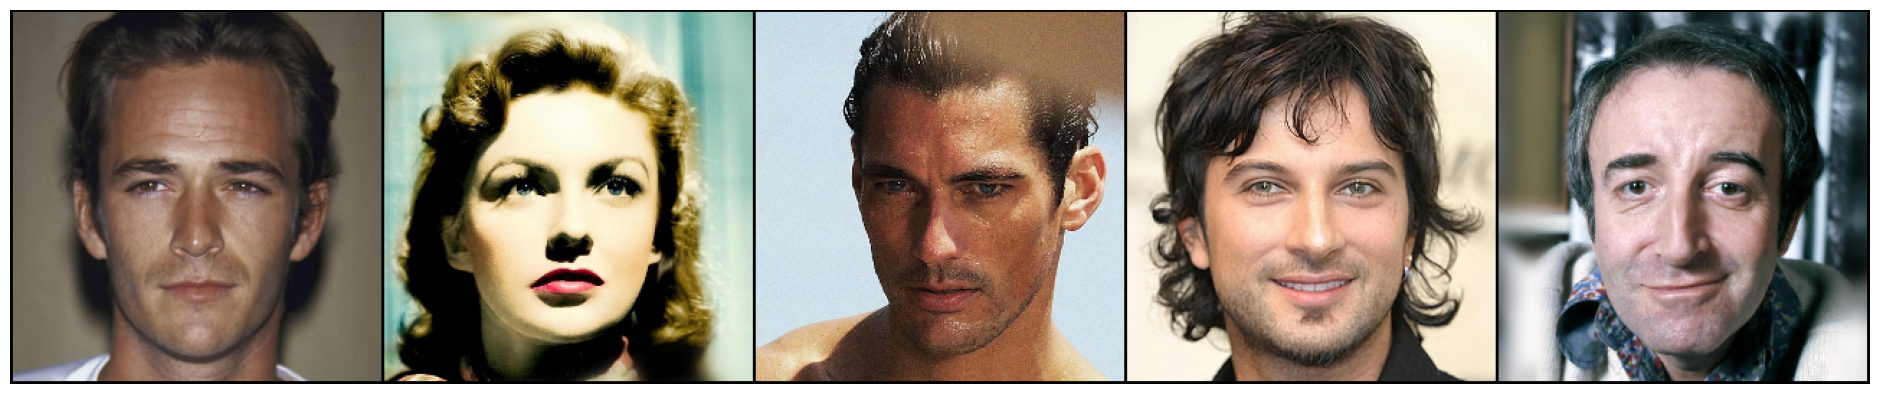

In [35]:
visualize_grid(images, nrow=10)

In [36]:
#To check if pfode.py is working
from main.pfode import PFODE
pf_ode = PFODE(model.edm_scheduler, model, (5, *model.get_in_shape()))
z_T = pf_ode.gaussian_prior_x_T(5)
z_0 = pf_ode.solve(z_T)
x_0 = model.decode(z_0)

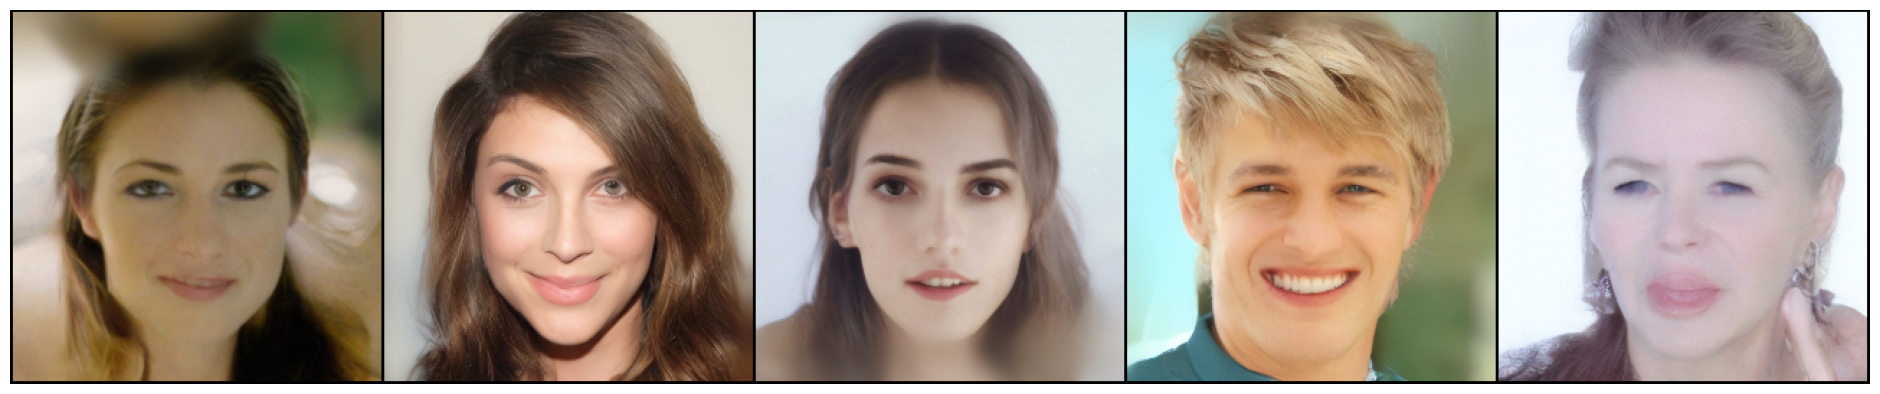

In [37]:
visualize_grid(x_0)

In [ ]:
#Load an operator using a config file
task_config_yaml = 'configs/task/phase_retrieval.yaml'
task_group = 'ldm'
task_config = OmegaConf.load(task_config_yaml)
mcmc_sampler_config = task_config[task_group].mcmc_sampler_config
operator_config = task_config[task_group].operator


In [20]:
mcmc_sampler_config

{'num_steps': 65, 'lr': 2.1e-05, 'tau': 0.01, 'lr_min_ratio': 0.12, 'momentum': 0.41, 'mc_algo': 'hmc', 'prior_solver': 'gaussian'}

In [21]:
from forward_operator import get_operator
operator = get_operator(**operator_config)
measurement = operator.measure(images.to("cuda"))

In [22]:
from torch.nn.functional import interpolate

def resize(y, x, task_name):
    if y.shape != x.shape:
        ry = interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)
    else:
        ry = y
    if task_name == 'phase_retrieval':
        def norm_01(y):
            tmp = (y - y.mean()) / y.std()
            tmp = tmp.clip(-0.5, 0.5) * 3
            return tmp

        ry = norm_01(ry) * 2 - 1
    return ry

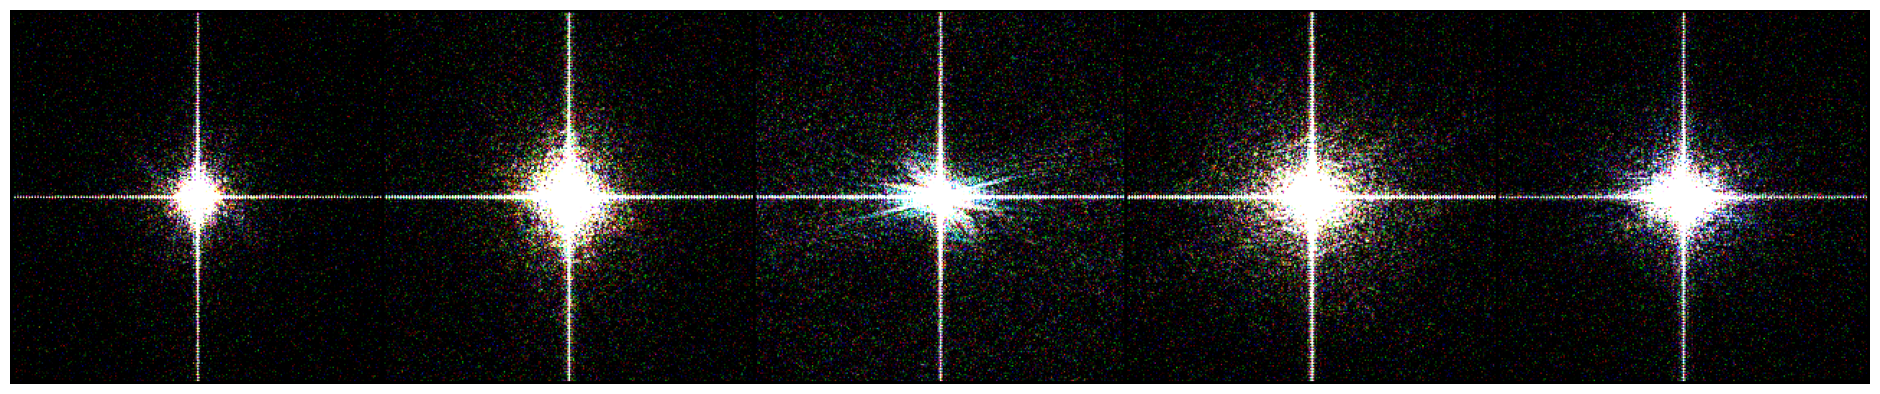

In [23]:
#Measurement works
resized_measurement = resize(measurement, images, operator_config.name)
visualize_grid(resized_measurement, nrow=5)

In [24]:
x_0.requires_grad
x_0_rq_grad = x_0.clone().detach().requires_grad_(True)
x_0_rq_grad.requires_grad

True

In [25]:
#To check if Langevian is working
from daps_sampler import MCMC_Langevin

mcmc_lv = MCMC_Langevin(eta = mcmc_sampler_config['lr'], beta_y = mcmc_sampler_config['tau'], iter = mcmc_sampler_config['num_steps'])
x0_cond, x0_cond_list = mcmc_lv.mcmc_chain(x0_hat= x_0, measurement=measurement.to("cuda"), operator=operator, r_t = 100)


100%|██████████████████████████████████████████| 65/65 [00:00<00:00, 200.56it/s]


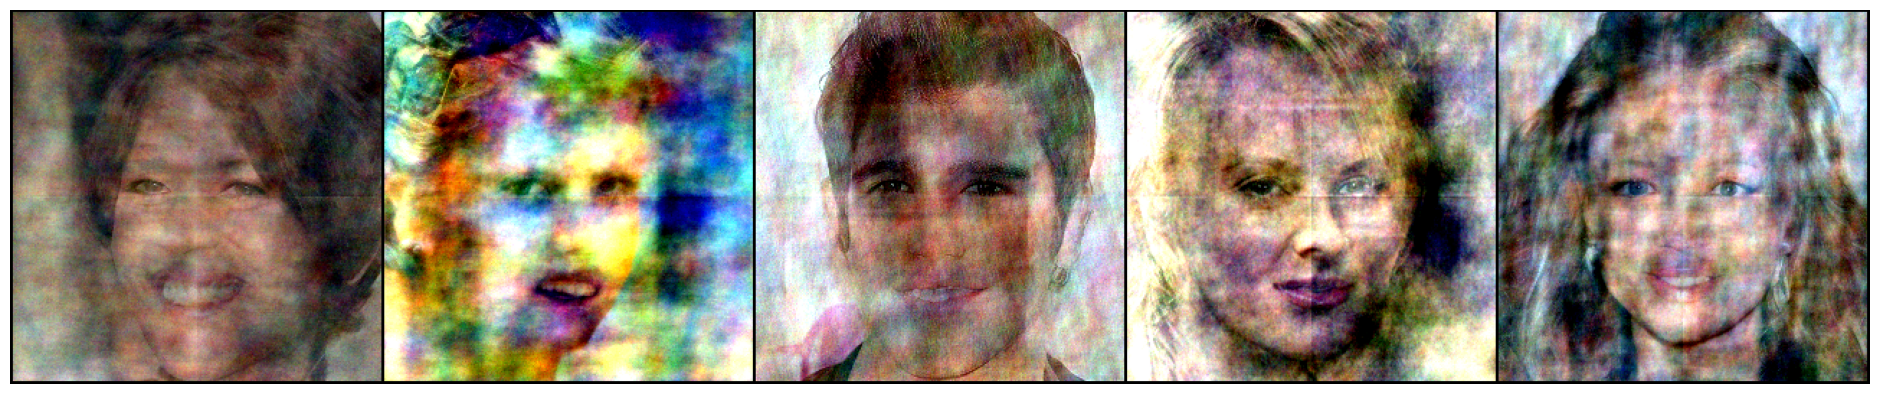

In [67]:
visualize_grid(x0_cond, nrow=5)

In [27]:
daps_config

{'latent': False, 'annealing_scheduler_config': {'name': 'edm', 'num_steps': 200, 'sigma_max': 100, 'sigma_min': 0.1, 'timestep': 'poly-7'}, 'diffusion_scheduler_config': {'name': 'edm', 'num_steps': 5, 'sigma_min': 0.01, 'timestep': 'poly-7'}}

In [28]:
#To check if DAPS is working
from daps_sampler import LatentDAPS
latentdaps = LatentDAPS(daps_config['annealing_scheduler_config'], daps_config['diffusion_scheduler_config'], mcmc_sampler_config)
z_init = pf_ode.gaussian_prior_x_T(5)
x_final = latentdaps.latent_daps_sample(model, z_init, operator, measurement)

 36%|██████████████▌                         | 73/200 [56:47<1:38:48, 46.68s/it]


KeyboardInterrupt: 

In [ ]:
visualize_grid(x_final, nrow=5)